# Run code without calibration

/var/folders/m1/qxpcclg55hg_8gcmt4vpkrq80000gn/T/ipykernel_25458/145668510.py:50: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


Starting 10s data collection...
✅ Connected to MQTT broker
📡 Samples collected: 266
📦 Total collection time: 10.05 sec

──── IMU Sampling Summary ────
Samples received: 266
Average frequency: 26.55 Hz
Mean interval: 37.665 ms
Jitter: 0.555 ms

💾 Data saved to: data/imu_data_20251120_182806_266samples_10s.csv


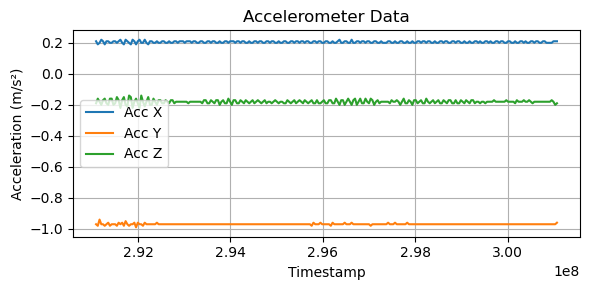

In [3]:
import paho.mqtt.client as mqtt
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import time
from datetime import datetime
import os

# ─── Config ────────────────────────────────────────────────
BROKER_ADDRESS = "127.0.0.1"
MQTT_TOPIC = "imu/data"
RECORD_SECONDS = 10          # duration to record, in seconds
OUTPUT_DIR = "data"          # folder to save CSV files

os.makedirs(OUTPUT_DIR, exist_ok=True)

imu_data = []
collecting = True

# ─── MQTT Callbacks ─────────────────────────────────────────
def on_connect(client, userdata, flags, rc):
    if rc == 0:
        print("✅ Connected to MQTT broker")
        client.subscribe(MQTT_TOPIC)
    else:
        print(f"❌ Connection failed with code {rc}")

def on_message(client, userdata, msg):
    global imu_data, collecting
    if not collecting:
        return

    payload = msg.payload.decode("utf-8").strip()

    # Extract 8 numerical values inside [[...]]
    match = re.findall(r"\[([0-9\.,\- ]+)\]", payload)
    if not match:
        return

    values = [float(v) for v in match[0].split(",")]

    # Expecting 8 values: timestamp, seq, acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z
    if len(values) == 8:
        imu_data.append(values)

    print(f"📡 Samples collected: {len(imu_data)}", end="\r")

# ─── Collect Data for a Fixed Duration ──────────────────────
client = mqtt.Client()
client.on_connect = on_connect
client.on_message = on_message

print(f"Starting {RECORD_SECONDS}s data collection...")
client.connect(BROKER_ADDRESS, 1883, 60)
client.loop_start()

start_time = time.time()
while time.time() - start_time < RECORD_SECONDS:
    time.sleep(0.05)

collecting = False
client.loop_stop()
client.disconnect()

elapsed = time.time() - start_time
print(f"\n📦 Total collection time: {elapsed:.2f} sec")

# ─── Convert to DataFrame ───────────────────────────────────
if len(imu_data) == 0:
    print("⚠️ No data received.")
else:

    # Correct 8-column format
    columns = ["timestamp", "seq", "acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]
    df = pd.DataFrame(imu_data, columns=columns)

    # Compute timing metrics (from timestamps)
    df["dt"] = df["timestamp"].diff()
    df.loc[df["dt"] < 0, "dt"] += 2**32  # micros rollover

    df["dt_sec"] = df["dt"] / 1_000_000.0

    avg_freq = 1 / df["dt_sec"].mean()
    jitter_ms = df["dt_sec"].std() * 1000

    print("\n──── IMU Sampling Summary ────")
    print(f"Samples received: {len(df)}")
    print(f"Average frequency: {avg_freq:.2f} Hz")
    print(f"Mean interval: {df['dt_sec'].mean()*1000:.3f} ms")
    print(f"Jitter: {jitter_ms:.3f} ms")

    # ─── Save to CSV ─────────────────────────────────────────
    date_str = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"imu_data_{date_str}_{len(df)}samples_{RECORD_SECONDS}s.csv"
    filepath = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(filepath, index=False)
    print(f"\n💾 Data saved to: {filepath}")

    # ─── Visualization ───────────────────────────────────────
    plt.figure(figsize=(6, 3))
    plt.plot(df["timestamp"], df["acc_x"], label="Acc X")
    plt.plot(df["timestamp"], df["acc_y"], label="Acc Y")
    plt.plot(df["timestamp"], df["acc_z"], label="Acc Z")
    plt.legend()
    plt.title("Accelerometer Data")
    plt.xlabel("Timestamp")
    plt.ylabel("Acceleration (m/s²)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Run code with calibration

/var/folders/m1/qxpcclg55hg_8gcmt4vpkrq80000gn/T/ipykernel_68276/94763351.py:45: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


Starting 10s data collection...
✅ Connected to MQTT broker
📡 Samples collected: 270
📦 Total collection time: 10.03 sec

──── IMU Sampling Summary ────
Samples received: 270
Average frequency: 27.04 Hz
Mean interval: 36.976 ms
Jitter: 0.381 ms

💾 Data saved to: data/imu_data_20251120_103657_270samples_10s.csv


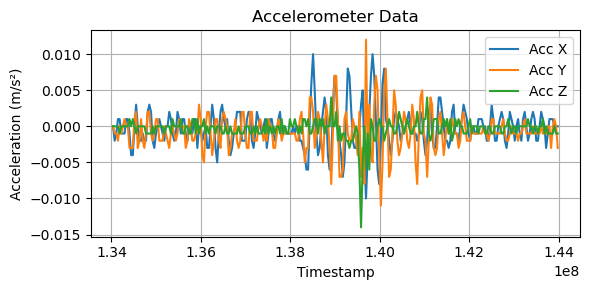

In [ ]:
import paho.mqtt.client as mqtt
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import time
from datetime import datetime
import os

# ─── Config ────────────────────────────────────────────────
BROKER_ADDRESS = "127.0.0.1"
MQTT_TOPIC = "imu/data"
RECORD_SECONDS = 10          # duration to record, in seconds
OUTPUT_DIR = "data"          # folder to save CSV files

os.makedirs(OUTPUT_DIR, exist_ok=True)

imu_data = []
collecting = True

# ─── MQTT Callbacks ─────────────────────────────────────────
def on_connect(client, userdata, flags, rc):
    if rc == 0:
        print("✅ Connected to MQTT broker")
        client.subscribe(MQTT_TOPIC)
    else:
        print(f"❌ Connection failed with code {rc}")

def on_message(client, userdata, msg):
    global imu_data, collecting
    if not collecting:
        return

    payload = msg.payload.decode("utf-8").strip()

    # Extract 8 numerical values inside [[...]]
    match = re.findall(r"\[([0-9\.,\- ]+)\]", payload)
    if not match:
        return

    values = [float(v) for v in match[0].split(",")]

    # Expecting 8 values: timestamp, seq, acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z
    if len(values) == 8:
        imu_data.append(values)

    print(f"📡 Samples collected: {len(imu_data)}", end="\r")

# ─── Collect Data for a Fixed Duration ──────────────────────
client = mqtt.Client()
client.on_connect = on_connect
client.on_message = on_message

print(f"Starting {RECORD_SECONDS}s data collection...")
client.connect(BROKER_ADDRESS, 1883, 60)
client.loop_start()

start_time = time.time()
while time.time() - start_time < RECORD_SECONDS:
    time.sleep(0.05)

collecting = False
client.loop_stop()
client.disconnect()

elapsed = time.time() - start_time
print(f"\n📦 Total collection time: {elapsed:.2f} sec")

# ─── Convert to DataFrame ───────────────────────────────────
if len(imu_data) == 0:
    print("⚠️ No data received.")
else:

    # Correct 8-column format
    columns = ["timestamp", "seq", "acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]
    df = pd.DataFrame(imu_data, columns=columns)

    # Compute timing metrics (from timestamps)
    df["dt"] = df["timestamp"].diff()
    df.loc[df["dt"] < 0, "dt"] += 2**32  # micros rollover

    df["dt_sec"] = df["dt"] / 1_000_000.0

    avg_freq = 1 / df["dt_sec"].mean()
    jitter_ms = df["dt_sec"].std() * 1000

    print("\n──── IMU Sampling Summary ────")
    print(f"Samples received: {len(df)}")
    print(f"Average frequency: {avg_freq:.2f} Hz")
    print(f"Mean interval: {df['dt_sec'].mean()*1000:.3f} ms")
    print(f"Jitter: {jitter_ms:.3f} ms")

    # ─── Save to CSV ─────────────────────────────────────────
    date_str = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"imu_data_{date_str}_{len(df)}samples_{RECORD_SECONDS}s.csv"
    filepath = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(filepath, index=False)
    print(f"\n💾 Data saved to: {filepath}")

    # ─── Visualization ───────────────────────────────────────
    plt.figure(figsize=(6, 3))
    plt.plot(df["timestamp"], df["acc_x"], label="Acc X")
    plt.plot(df["timestamp"], df["acc_y"], label="Acc Y")
    plt.plot(df["timestamp"], df["acc_z"], label="Acc Z")
    plt.legend()
    plt.title("Accelerometer Data")
    plt.xlabel("Timestamp")
    plt.ylabel("Acceleration (m/s²)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
